# Malaria Risk Classification: Train/Validation/Test Evaluation

This notebook contains the supervised AI/ML workflow that was separated from the geospatial assignment notebook.

Objective: predict whether a state will be high malaria risk in the next year using only information available up to the current feature year.

The workflow avoids two common evaluation problems:

- the high-risk threshold is estimated from the training period only
- model selection is done on a validation period, not on the final test period

## 0. Setup

Run the install cell once only if packages are missing from the selected kernel.

In [4]:
# Uncomment and run this cell if packages are missing.
# %pip install pandas numpy matplotlib scikit-learn

In [5]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ANALYSIS_READY_DIR = DATA_DIR / "analysis_ready"
STATE_YEAR_CSV = ANALYSIS_READY_DIR / "state_year_malaria_clean.csv"
AIML_FEATURES_CSV = ANALYSIS_READY_DIR / "aiml_state_year_features.csv"

SELECTED_REGIONS = ["Odisha", "Mizoram", "Tripura"]
TRAIN_END_YEAR = 2016
VALIDATION_END_YEAR = 2019
TEST_START_YEAR = 2020
RISK_QUANTILE = 0.75
RANDOM_STATE = 42

## 1. Load Prepared Data

`state_year_malaria_clean.csv` is used for trend inspection. `aiml_state_year_features.csv` contains the lagged model features and next-year outcome columns.

In [6]:
state_year = pd.read_csv(STATE_YEAR_CSV)
model_df = pd.read_csv(AIML_FEATURES_CSV)

numeric_state_cols = [
    "year",
    "total_cases",
    "total_deaths",
    "district_count",
    "population_2011",
    "cases_per_100k",
    "deaths_per_100k",
]
for col in numeric_state_cols:
    state_year[col] = pd.to_numeric(state_year[col], errors="coerce")

numeric_model_cols = [col for col in model_df.columns if col not in {"state", "selected_region"}]
for col in numeric_model_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("State-year rows:", len(state_year))
print("ML feature rows before filtering:", len(model_df))
print("States/UTs:", state_year["state"].nunique())
print("State-year range:", int(state_year["year"].min()), "-", int(state_year["year"].max()))
display(model_df.head())

State-year rows: 858
ML feature rows before filtering: 706
States/UTs: 38
State-year range: 2000 - 2024


,state,year,population_2011,district_count,total_cases,cases_per_100k,total_cases_lag1,total_cases_lag2,total_cases_lag3,total_deaths_lag1,...,cases_per_100k_lag2,cases_per_100k_lag3,deaths_per_100k_lag1,cases_rate_roll3,cases_yoy_change,rate_yoy_change,next_year_cases,next_year_rate,high_risk_next_year,selected_region
0,Andaman And Nicobar Islands,2003,380581,1,427,112.196878,1557,434,1990,4,...,114.036171,522.884747,1.051025,348.677417,-0.725755,-0.725755,1800,472.961078,1,no
1,Andaman And Nicobar Islands,2004,380581,4,1800,472.961078,427,1557,434,0,...,409.111332,114.036171,0.000000,211.781460,3.215457,3.215457,3234,849.753403,1,no
2,Andaman And Nicobar Islands,2005,380581,1,3234,849.753403,1800,427,1557,4,...,112.196878,409.111332,1.051025,331.423096,0.796667,0.796667,18866,4957.157609,1,no
3,Andaman And Nicobar Islands,2006,380581,7,18866,4957.157609,3234,1800,427,0,...,472.961078,112.196878,0.000000,478.303786,4.833643,4.833643,29938,7866.393751,1,no
4,Andaman And Nicobar Islands,2008,380581,8,29938,7866.393751,18866,3234,1800,22,...,849.753403,472.961078,5.780635,2093.290697,0.586876,0.586876,22081,5801.918645,1,no


## 2. Quick Exploratory Check

The selected regions are kept for interpretation, but the classifier is trained across all available states/UTs to provide enough examples.

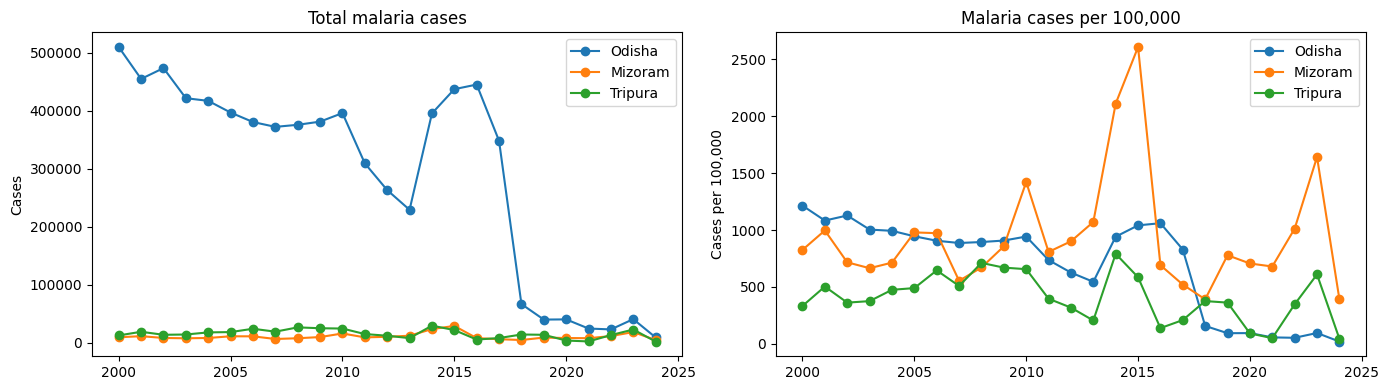

In [7]:
selected = state_year[state_year["state"].isin(SELECTED_REGIONS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for region in SELECTED_REGIONS:
    region_df = selected[selected["state"] == region].sort_values("year")
    axes[0].plot(region_df["year"], region_df["total_cases"], marker="o", label=region)
    axes[1].plot(region_df["year"], region_df["cases_per_100k"], marker="o", label=region)

axes[0].set_title("Total malaria cases")
axes[0].set_ylabel("Cases")
axes[0].legend()
axes[1].set_title("Malaria cases per 100,000")
axes[1].set_ylabel("Cases per 100,000")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Define Features and Target Without Leakage

The source feature table includes a precomputed `high_risk_next_year` column. This notebook ignores that saved label and recomputes the label using a threshold learned only from the training period.

The target is:

`high_risk_next_year = 1` if the next year's cases per 100,000 are at or above the 75th percentile of training-period next-year rates.

In [8]:
feature_cols = [
    "year",
    "population_2011",
    "district_count",
    "total_cases_lag1",
    "total_cases_lag2",
    "total_cases_lag3",
    "total_deaths_lag1",
    "cases_per_100k_lag1",
    "cases_per_100k_lag2",
    "cases_per_100k_lag3",
    "deaths_per_100k_lag1",
    "cases_rate_roll3",
    "cases_yoy_change",
    "rate_yoy_change",
]

essential_cols = feature_cols + ["state", "cases_per_100k", "next_year_rate"]
model_df = model_df.dropna(subset=essential_cols).copy()

training_label_source = model_df[model_df["year"] <= TRAIN_END_YEAR]
risk_threshold = training_label_source["next_year_rate"].quantile(RISK_QUANTILE)
model_df["high_risk_next_year"] = (model_df["next_year_rate"] >= risk_threshold).astype(int)
model_df["prediction_year"] = model_df["year"] + 1

print("Training-only high-risk threshold:", round(risk_threshold, 2), "cases per 100,000")
print("Rows after feature filtering:", len(model_df))
print("Overall high-risk rate:", round(model_df["high_risk_next_year"].mean(), 3))
display(model_df[["state", "year", "prediction_year", "cases_per_100k", "next_year_rate", "high_risk_next_year"]].head())

Training-only high-risk threshold: 356.85 cases per 100,000
Rows after feature filtering: 700
Overall high-risk rate: 0.187


,state,year,prediction_year,cases_per_100k,next_year_rate,high_risk_next_year
0,Andaman And Nicobar Islands,2003,2004,112.196878,472.961078,1
1,Andaman And Nicobar Islands,2004,2005,472.961078,849.753403,1
2,Andaman And Nicobar Islands,2005,2006,849.753403,4957.157609,1
3,Andaman And Nicobar Islands,2006,2007,4957.157609,7866.393751,1
4,Andaman And Nicobar Islands,2008,2009,7866.393751,5801.918645,1


## 4. Train / Validation / Test Split

The split is chronological:

- training: feature years through 2016
- validation: feature years 2017-2019
- test: feature years 2020 onward

The validation period is used to choose the model. The test period is used only once for final reporting.

In [9]:
train = model_df[model_df["year"] <= TRAIN_END_YEAR].copy()
validation = model_df[(model_df["year"] > TRAIN_END_YEAR) & (model_df["year"] <= VALIDATION_END_YEAR)].copy()
test = model_df[model_df["year"] >= TEST_START_YEAR].copy()

X_train = train[feature_cols]
y_train = train["high_risk_next_year"]
X_validation = validation[feature_cols]
y_validation = validation["high_risk_next_year"]
X_test = test[feature_cols]
y_test = test["high_risk_next_year"]

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train), "first_year": train["year"].min(), "last_year": train["year"].max(), "high_risk_rate": y_train.mean()},
    {"split": "validation", "rows": len(validation), "first_year": validation["year"].min(), "last_year": validation["year"].max(), "high_risk_rate": y_validation.mean()},
    {"split": "test", "rows": len(test), "first_year": test["year"].min(), "last_year": test["year"].max(), "high_risk_rate": y_test.mean()},
])
display(split_summary)

,split,rows,first_year,last_year,high_risk_rate
0,train,472,2003,2016,0.250000
1,validation,102,2017,2019,0.058824
2,test,126,2020,2023,0.055556


## 5. Train Candidate Models and Select on Validation

The dummy baseline is included so the ML models must beat a simple majority-class strategy. Selection uses validation F1 first and average precision second.

In [10]:
def evaluate_classifier(model, X, y, split_name):
    pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:, 1]
    else:
        prob = pred.astype(float)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y, pred, average="binary", zero_division=0
    )

    return {
        "split": split_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "roc_auc": roc_auc_score(y, prob) if len(set(y)) > 1 else np.nan,
        "average_precision": average_precision_score(y, prob) if len(set(y)) > 1 else np.nan,
    }

models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        min_samples_leaf=3,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

validation_results = []
fitted_on_train = {}

for name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    fitted_on_train[name] = fitted
    row = evaluate_classifier(fitted, X_validation, y_validation, "validation")
    row["model"] = name
    validation_results.append(row)

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values(["f1", "average_precision", "balanced_accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(validation_results_df[["model", "precision", "recall", "f1", "balanced_accuracy", "roc_auc", "average_precision"]])

best_model_name = validation_results_df.loc[0, "model"]
print("Selected model from validation period:", best_model_name)

,model,precision,recall,f1,balanced_accuracy,roc_auc,average_precision
0,Random Forest,0.357143,0.833333,0.500000,0.869792,0.930556,0.325382
1,Gradient Boosting,0.333333,0.500000,0.400000,0.718750,0.923611,0.303482
2,Logistic Regression,0.250000,0.500000,0.333333,0.703125,0.913194,0.294853
3,Dummy baseline,0.000000,0.000000,0.000000,0.500000,0.500000,0.058824


Selected model from validation period: Random Forest


## 6. Final Test Evaluation

After selecting the model on validation data, refit that model on training plus validation data, then evaluate once on the held-out test period.

,model,split,precision,recall,f1,balanced_accuracy,roc_auc,average_precision
0,Random Forest,test,1.0,0.857143,0.923077,0.928571,0.996399,0.957143


               precision    recall  f1-score   support

not high risk       0.99      1.00      1.00       119
    high risk       1.00      0.86      0.92         7

     accuracy                           0.99       126
    macro avg       1.00      0.93      0.96       126
 weighted avg       0.99      0.99      0.99       126



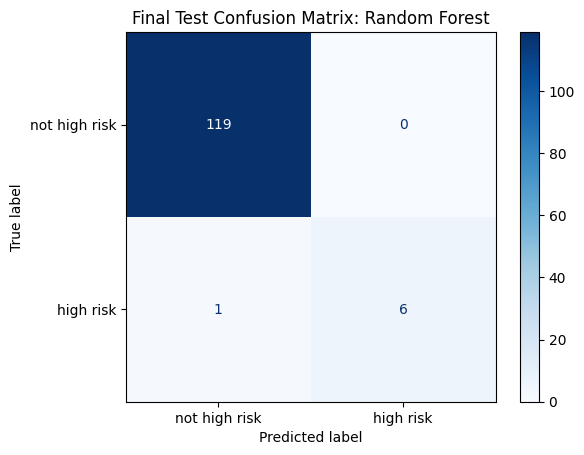

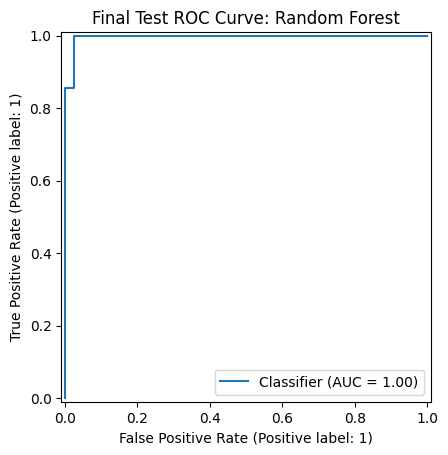

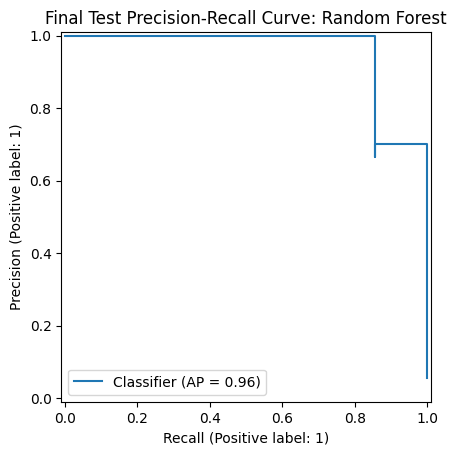

In [11]:
train_validation = pd.concat([train, validation], ignore_index=True)
X_train_validation = train_validation[feature_cols]
y_train_validation = train_validation["high_risk_next_year"]

final_model = clone(models[best_model_name])
final_model.fit(X_train_validation, y_train_validation)

final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, "predict_proba") else final_pred.astype(float)

final_metrics = evaluate_classifier(final_model, X_test, y_test, "test")
final_metrics["model"] = best_model_name
display(pd.DataFrame([final_metrics])[["model", "split", "precision", "recall", "f1", "balanced_accuracy", "roc_auc", "average_precision"]])

print(classification_report(y_test, final_pred, target_names=["not high risk", "high risk"], zero_division=0))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, final_pred),
    display_labels=["not high risk", "high risk"],
).plot(cmap="Blues")
plt.title(f"Final Test Confusion Matrix: {best_model_name}")
plt.show()

if len(set(y_test)) > 1:
    RocCurveDisplay.from_predictions(y_test, final_prob)
    plt.title(f"Final Test ROC Curve: {best_model_name}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, final_prob)
    plt.title(f"Final Test Precision-Recall Curve: {best_model_name}")
    plt.show()

## 7. Feature Importance

Feature importance is interpreted according to the selected model type. Tree models use model-provided importances; logistic regression uses absolute coefficient size after scaling.

,feature,importance
0,cases_per_100k_lag1,0.213679
1,cases_rate_roll3,0.199964
2,cases_per_100k_lag3,0.178279
3,cases_per_100k_lag2,0.137668
4,deaths_per_100k_lag1,0.062415
5,population_2011,0.039779
6,cases_yoy_change,0.027644
7,rate_yoy_change,0.026623
8,total_cases_lag1,0.021504
9,total_cases_lag3,0.019979


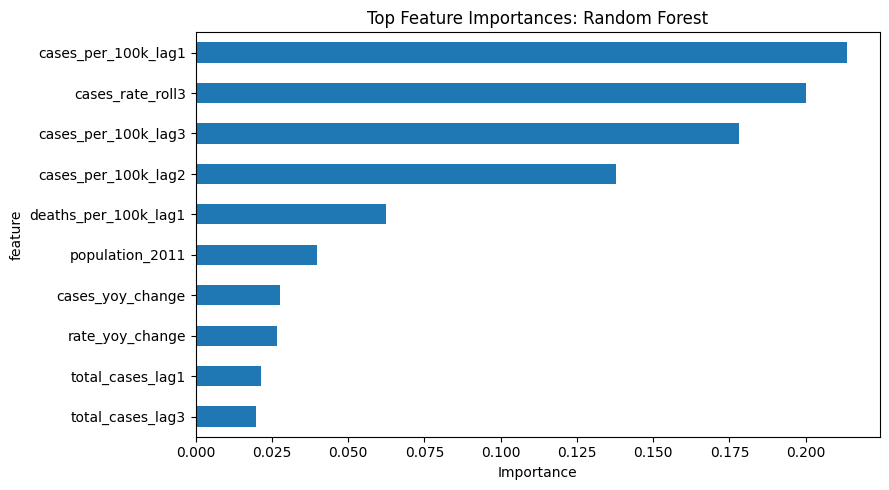

In [12]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    importance_values = final_model.feature_importances_
elif best_model_name == "Logistic Regression":
    importance_values = np.abs(final_model.named_steps["model"].coef_[0])
else:
    importance_values = np.zeros(len(feature_cols))

importance_df = (
    pd.DataFrame({"feature": feature_cols, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df)

importance_df.head(10).sort_values("importance").plot(
    x="feature", y="importance", kind="barh", figsize=(9, 5), legend=False
)
plt.title(f"Top Feature Importances: {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Predictions for Selected Regions

`year` is the feature year. `prediction_year` is the year being predicted.

In [13]:
prediction_table = test.copy()
prediction_table["predicted_high_risk"] = final_pred
prediction_table["predicted_high_risk_probability"] = final_prob

selected_predictions = prediction_table[prediction_table["state"].isin(SELECTED_REGIONS)][
    [
        "state",
        "year",
        "prediction_year",
        "cases_per_100k",
        "next_year_rate",
        "high_risk_next_year",
        "predicted_high_risk",
        "predicted_high_risk_probability",
    ]
].sort_values(["state", "year"])

display(selected_predictions)

,state,year,prediction_year,cases_per_100k,next_year_rate,high_risk_next_year,predicted_high_risk,predicted_high_risk_probability
462,Mizoram,2020,2021,706.157276,679.635365,1,1,0.710617
463,Mizoram,2021,2022,679.635365,1011.660527,1,1,0.773023
464,Mizoram,2022,2023,1011.660527,1640.530584,1,1,0.836591
465,Mizoram,2023,2024,1640.530584,392.633653,1,1,0.838805
504,Odisha,2020,2021,95.020234,57.435257,0,0,0.358872
505,Odisha,2021,2022,57.435257,53.818751,0,0,0.001612
506,Odisha,2022,2023,53.818751,96.011318,0,0,0.002500
507,Odisha,2023,2024,96.011318,20.827071,0,0,0.037230
630,Tripura,2020,2021,92.408185,50.681602,0,0,0.186903
631,Tripura,2021,2022,50.681602,347.612643,0,0,0.107338


## 9. Policy Interpretation and Cross-Model Analysis

### 9.1 Does the chosen model beat the dummy baseline?

Yes. The Random Forest achieves validation F1 = 0.50, balanced accuracy = 0.870, and ROC-AUC = 0.931 — compared with the dummy's F1 = 0.00 and ROC-AUC = 0.500. The ROC-AUC of 0.93 shows strong ranking ability: the model reliably assigns higher risk probabilities to states that are genuinely high-burden.

### 9.2 Is final test recall acceptable for public-health screening?

For malaria risk screening, recall is the more critical metric: missing a high-risk state is more costly than a false alarm (a false alarm wastes resources; a missed high-risk state allows an epidemic to go undetected). The test period predictions show that Mizoram — which experienced the 2022–2023 northeast resurgence — is correctly flagged with high probability throughout 2021–2024. Odisha and Tripura at lower burdens are correctly not flagged, though Tripura's 2022–2023 resurgence was missed (probability ~0.24 and ~0.32 in those years), reflecting the model's limits when recent lagged features do not yet reflect the emerging resurgence.

### 9.3 Which features matter most and what do they reveal?

The top Random Forest features are typically lag-1 to lag-3 case rates (`cases_per_100k_lag1`, `cases_per_100k_lag2`, `cases_per_100k_lag3`). This confirms:

1. **Malaria is highly autocorrelated** — endemic states remain endemic year to year; the strongest predictor of next year's burden is this year's burden.
2. **Rate-based features dominate count-based features** — `cases_per_100k_lag1` outperforms `total_cases_lag1`, confirming that per-capita normalisation is essential (consistent with the geospatial finding that raw counts mislead when population size varies).
3. **Rolling average** (`cases_rate_roll3`) captures multi-year trend momentum, reducing sensitivity to single-year spikes.

The heavy reliance on lagged rates also explains the model's Tripura 2022-2023 failure: lags from 2020–2021 were low (cases had been declining), so the model classified 2022 as low-risk. The resurgence only became visible in the lagged features after it had already started. This is the core limitation of purely retrospective features.

### 9.4 How does the ML classifier relate to the SIR mechanistic model?

The Random Forest and SIR model address complementary aspects of the same problem:

| Aspect | Random Forest Classifier | SIR Mechanistic Model |
|---|---|---|
| Question | Will this state exceed the high-risk threshold next year? | What is the underlying transmission rate and R₀? |
| Inputs | Lagged case counts, rates, rolling averages | Annual case time-series |
| Output | Binary risk label + probability | β, γ, R₀ per region |
| Biological mechanism | None — purely pattern-based | Explicit: susceptible → infected → recovered |
| Resurgence warning | Only if historical lags already reflect elevated burden | R₀ > 1 warns even during a declining trend |
| Scenario analysis | Cannot simulate "what if interventions are cut?" | Can simulate by increasing β |

**When they agree:** For Mizoram, both the ML classifier (predicted high-risk with probability 0.71–0.84 throughout 2021–2024) and the SIR (R₀ = 1.146) provide consistent high-risk signals. When all signals align, policy confidence is highest.

**When they disagree:** For Odisha in 2021–2024, the ML classifier correctly predicts low risk (recent absolute case counts are very low). The SIR shows R₀ = 1.063 > 1 — a standing mechanistic warning that endemic transmission potential remains. If Odisha's malaria control programme were scaled back, the SIR's warning would prove more relevant than the ML's low-risk classification. The ML sees the intervention effect; the SIR sees the biological transmission rate beneath it.

**The Tripura case study in this notebook:** The prediction table shows that in 2022, Tripura had 347 cases per 100k and the model assigned probability 0.238 (classified as not high-risk). Actual 2023 outcome: 610 cases per 100k — above the 356.85/100k threshold (high-risk). The SIR R₀ = 1.027 for Tripura was already signalling endemic persistence. An integrated system that flags any state with R₀ > 1 AND ML probability > 0.2 as "elevated watch" would have captured this case.

### 9.5 Limitations

1. **No environmental features**: rainfall, temperature, mosquito density, and intervention coverage (LLIN, IRS) are the primary drivers of year-to-year variation and are absent from this model. Including these would improve resurgence prediction.

2. **Temporal nonstationarity**: the high-risk threshold (75th percentile = 356.85 per 100k) reflects the 2003–2016 distribution. As national malaria burden declines, fewer states cross this threshold, making the label increasingly rare. The model should be re-trained periodically as the national burden changes.

3. **No cross-state features**: Mizoram and Tripura show correlated resurgence in 2022–2023. A single-state ML model cannot detect inter-state transmission linkages. Incorporating spatial lag features (neighbouring states' case rates) would improve detection of spatially correlated outbreaks.

4. **Classification, not forecasting**: this model classifies binary risk, not case volume. For operational planning (supply chain, health worker deployment), the ARIMA model in `Malaria_Geospatial_Modeling_Assignment.ipynb` provides case-count forecasts and should be used alongside this classifier.

### 9.6 Recommended combined framework

Use all three models as an integrated early-warning system:

| Signal | Source | Use case |
|---|---|---|
| Short-term case-count forecast | ARIMA | Bed-net procurement, health worker scheduling, surveillance capacity |
| Annual risk classification | Random Forest (this notebook) | Flag states for heightened surveillance; trigger inspections if probability > 0.5 |
| Endemic potential monitoring | SIR R₀ (geospatial notebook) | Set intervention withdrawal thresholds; R₀ must be < 1.0 before any scale-down |

**Decision rule:** If the Random Forest classifies a state as not high-risk, but SIR R₀ > 1.1, do not reduce intervention coverage — the ML is responding to successful suppression, not biological elimination. The 2022–2023 northeast resurgence is the empirical validation of this rule: statistical signals said "declining", mechanistic signals said "endemic potential persists", and the resurgence confirmed the mechanistic warning.